In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats 
import warnings 
warnings.filterwarnings('ignore') 

pd.set_option('display.max_columns', None) 
pd.set_option('display.float_format', '{:.4f}'.format) 
sns.set_theme(style='whitegrid', palette='muted') 
plt.rcParams['figure.figsize'] = (10, 5) 
plt.rcParams['font.size'] = 11

LOAD DATASET

In [101]:
df = pd.read_csv('produk_tokopedia.csv') 
print(f'Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom') 
df.head() 

Dataset berhasil dimuat: 29519 baris, 9 kolom


,Nama Produk,Nama Toko,Lokasi Toko,Terjual,Jumlah Ulasan,Rating,Harga (IDR),Diskon (%),Produk URL
0,Raw Food Beef Bone-In / Daging Giling / Dog Fo...,Lazy Dog Supply,Jakarta Selatan,1rb+ terjual,10 ulasan,5.0000,35000,0.0000,https://www.tokopedia.com/lazy-dog-supply/raw-...
1,Turkey Meat ONLY NO BONE - 1KG - Daging Kalkun...,RumahBully,Jakarta Timur,250+ terjual,NaN,5.0000,79999,0.0000,https://www.tokopedia.com/rumahbully/turkey-me...
2,Chicken mix Salmon Raw Food ayam mix salmon ma...,RumahBully,Jakarta Barat,26 terjual,NaN,5.0000,33000,0.0000,https://www.tokopedia.com/rumahbully/chicken-m...
3,PROMO BULANAN - SOSIS CHOP PREMIUM RAW - DOG F...,RumahBully,Tangerang Selatan,100+ terjual,NaN,5.0000,29900,0.0000,https://www.tokopedia.com/rumahbully/promo-bul...
4,Premium Dog Food / Daging Sapi Giling / Raw Fo...,RumahBully,Jakarta Selatan,1rb+ terjual,NaN,5.0000,39000,0.0000,https://www.tokopedia.com/rumahbully/premium-d...


In [102]:
print('=== INFO DATASET ===') 
df.info() 

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29519 entries, 0 to 29518
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Nama Produk    29519 non-null  object 
 1   Nama Toko      29469 non-null  object 
 2   Lokasi Toko    29379 non-null  object 
 3   Terjual        29290 non-null  object 
 4   Jumlah Ulasan  28260 non-null  object 
 5   Rating         29519 non-null  float64
 6   Harga (IDR)    29519 non-null  int64  
 7   Diskon (%)     29519 non-null  float64
 8   Produk URL     29519 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 2.0+ MB


DATA WRANGLING

In [103]:
import re

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

def clean_terjual(text):
    if pd.isna(text) or text == '': 
        return 0
    text = str(text).lower().replace('terjual', '').replace('+', '').strip()
    
    if 'rb' in text:
        text = text.replace('rb', '').replace(',', '.')
        multiplier = 1000
    else:
        text = text.replace('.', '')
        multiplier = 1
        
    try:
        return int(float(text) * multiplier)
    except ValueError:
        return 0
        
df['terjual'] = df['terjual'].apply(clean_terjual).astype(int)

if df['harga_(idr)'].dtype == 'object':
    df['harga_(idr)'] = df['harga_(idr)'].str.replace(r'\D', '', regex=True)
    df['harga_(idr)'] = pd.to_numeric(df['harga_(idr)'], errors='coerce').fillna(0)

df['nama_toko'] = df['nama_toko'].fillna('Unknown Shop')
df['lokasi_toko'] = df['lokasi_toko'].fillna('Indonesia')
df['jumlah_ulasan'] = df['jumlah_ulasan'].astype(str).str.replace(r'\D', '', regex=True)
df['jumlah_ulasan'] = pd.to_numeric(df['jumlah_ulasan'], errors='coerce').fillna(0).astype(int)

before_dup = len(df)
df.drop_duplicates(inplace=True)
after_dup = len(df)
print(f"Berhasil menghapus {before_dup - after_dup} baris duplikat.")

Berhasil menghapus 418 baris duplikat.


Proses ini dilakukan dengan beberapa rincian yaitu:
1. Nama kolom diganti dari format "Nama Toko" menjadi "nama_toko".
2. Memperbaiki data di kolom terjual agar terbaca sebagai data numerik.
3. Memastikan harga jadi numerik, hapus karakter non-digit jika perlu.
4. Data kosong di kolom nama_toko diisi Unknown Shop, dan di lokasi_toko diisi Indonesia.
5. Jumlah ulasan diganti menjadi string, lalu diubah menjadi numerik
6. Menghapus data duplikat dengan menggunakan df.drop_duplicates(inplace=True).

1. STATISTIK DESKRIPTIF

Statistik Deskriptif Numerik:
          terjual  jumlah_ulasan     rating    harga_(idr)  diskon_(%)
count  29101.0000     29101.0000 29101.0000     29101.0000  29101.0000
mean    1810.6938       263.5250     4.5733   1051427.2712     11.2673
std    13506.7018      2805.7764     1.2408  11090017.4605     20.3983
min        0.0000         0.0000     0.0000         0.0000      0.0000
25%        5.0000         0.0000     4.8000     36000.0000      0.0000
50%       40.0000         5.0000     5.0000     99500.0000      0.0000
75%      250.0000        50.0000     5.0000    321579.0000     14.0000
max   700000.0000    159200.0000     5.0000 900000000.0000     97.0000

Jumlah missing values per kolom:
nama_produk      0
nama_toko        0
lokasi_toko      0
terjual          0
jumlah_ulasan    0
rating           0
harga_(idr)      0
diskon_(%)       0
produk_url       0
dtype: int64

Distribusi nama_toko:
nama_toko
Tokopedia Seller        1211
three dots               410
Unknown Shop          

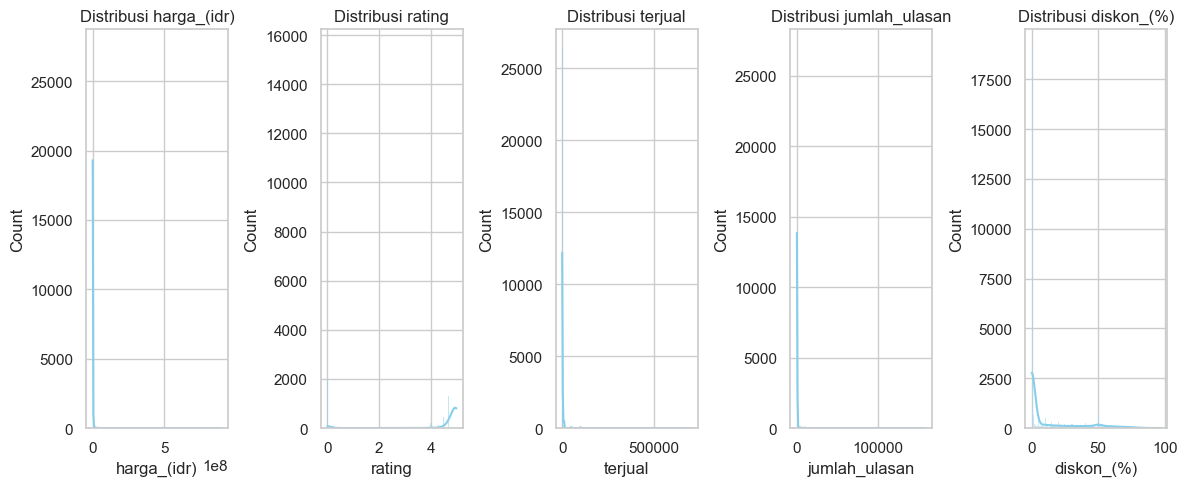

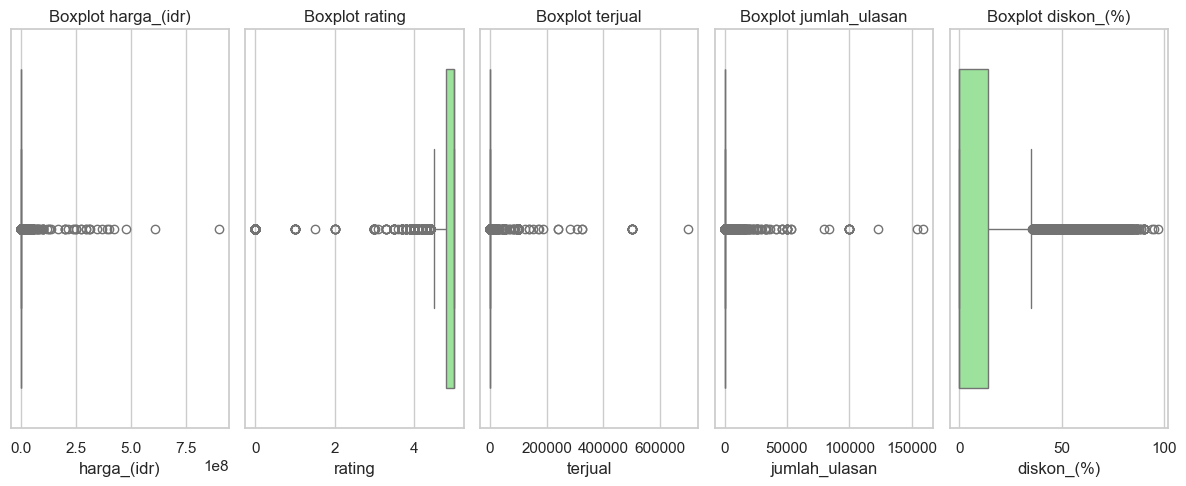

In [104]:
print("Statistik Deskriptif Numerik:")
print(df.describe())   

print("\nJumlah missing values per kolom:")
print(df.isnull().sum())

for col in ['nama_toko', 'lokasi_toko']:
    print(f"\nDistribusi {col}:")
    print(df[col].value_counts().head(10)) 

num_cols = ['harga_(idr)', 'rating', 'terjual', 'jumlah_ulasan', 'diskon_(%)']
plt.figure(figsize=(12, 5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()


Distribusi nama_toko:
nama_toko
tokopedia seller        1211
three dots               436
unknown shop             177
tokopedia                120
azko id                   83
click & go tokopedia      77
tokopedia merchant        75
ikea indonesia            68
unknown                   68
official store            65
Name: count, dtype: int64


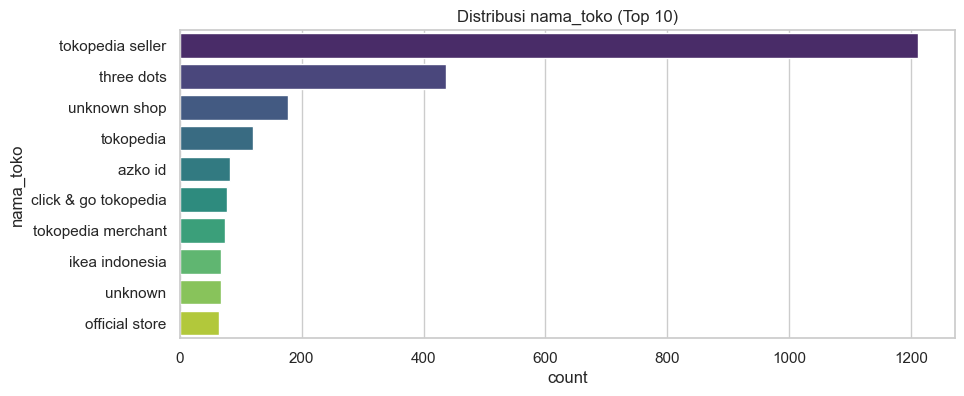


Distribusi lokasi_toko:
lokasi_toko
jakarta            4050
indonesia          2935
jakarta barat      2332
jakarta pusat      1502
jakarta utara      1327
kab. tangerang      936
jakarta selatan     872
surabaya            868
kota bandung        796
jakarta timur       771
Name: count, dtype: int64


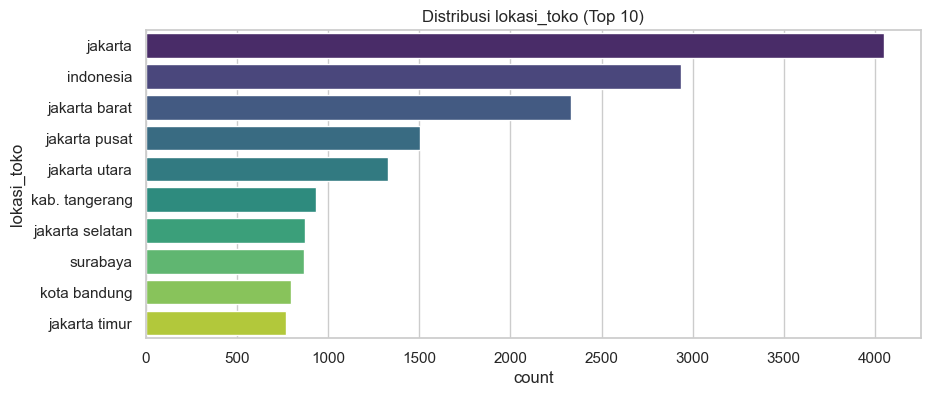

In [105]:
cat_cols = ['nama_toko', 'lokasi_toko']

for col in cat_cols:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.lower()
    df[col] = df[col].fillna('tidak diketahui')

for col in cat_cols:
    print(f"\nDistribusi {col}:")
    print(df[col].value_counts().head(10))

    plt.figure(figsize=(10,4))
    sns.countplot(y=df[col], order=df[col].value_counts().head(10).index, palette="viridis")
    plt.title(f"Distribusi {col} (Top 10)")
    plt.show()

In [106]:
n_before = len(df)
df = df[df['rating'] <= 5].copy()
n_after = len(df)
print(f'Data sebelum pembersihan : {n_before} baris')
print(f'Data setelah pembersihan : {n_after} baris')
print(f'Jumlah baris dihapus     : {n_before - n_after}')

print(
    'Alasan: Rating > 5 tidak valid '
    'karena sistem rating Tokopedia maksimal 5.'
)
print(
    f'\nDataset bersih siap dianalisis: '
    f'{df.shape[0]} baris, {df.shape[1]} kolom'
)

Data sebelum pembersihan : 29101 baris
Data setelah pembersihan : 29101 baris
Jumlah baris dihapus     : 0
Alasan: Rating > 5 tidak valid karena sistem rating Tokopedia maksimal 5.

Dataset bersih siap dianalisis: 29101 baris, 9 kolom


In [107]:
def clean_ulasan(text):
    if pd.isna(text):
        return 0
    text = str(text).lower()
    text = text.replace('ulasan', '').replace('.', '').strip()
    try:
        return int(text)
    except:
        return 0

df['jumlah_ulasan'] = df['jumlah_ulasan'].apply(clean_ulasan)

desc = df[num_cols].describe().T 
desc['skewness'] = df[num_cols].skew() 
desc['kurtosis'] = df[num_cols].kurt() 
desc['median'] = df[num_cols].median() 
desc['mode'] = df[num_cols].mode().iloc[0] 
desc['cv (%)'] = (df[num_cols].std() / df[num_cols].mean() * 100).round(2) 

print('Statistik Deskirptif Numerik Lanjutan') 
print(desc[['count','mean','median','mode','std','min','25%','50%','75%','max','skewness','kurtosis','cv (%)']])

Statistik Deskirptif Numerik Lanjutan
                   count         mean     median       mode           std  \
harga_(idr)   29101.0000 1051427.2712 99500.0000 35000.0000 11090017.4605   
rating        29101.0000       4.5733     5.0000     5.0000        1.2408   
terjual       29101.0000    1810.6938    40.0000   100.0000    13506.7018   
jumlah_ulasan 29101.0000     263.5250     5.0000     0.0000     2805.7764   
diskon_(%)    29101.0000      11.2673     0.0000     0.0000       20.3983   

                 min        25%        50%         75%            max  \
harga_(idr)   0.0000 36000.0000 99500.0000 321579.0000 900000000.0000   
rating        0.0000     4.8000     5.0000      5.0000         5.0000   
terjual       0.0000     5.0000    40.0000    250.0000    700000.0000   
jumlah_ulasan 0.0000     0.0000     5.0000     50.0000    159200.0000   
diskon_(%)    0.0000     0.0000     0.0000     14.0000        97.0000   

               skewness  kurtosis    cv (%)  
harga_(idr)   

Histogram dan Boxplot Rating Produk

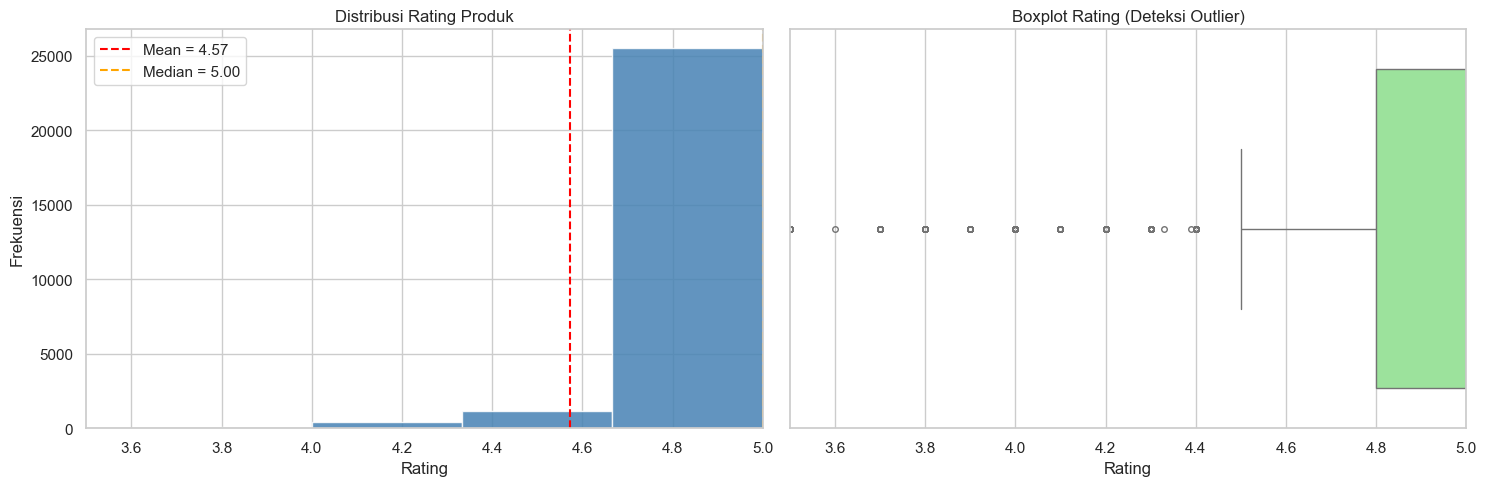

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['rating'], bins=15, color='steelblue', edgecolor='white', alpha=0.85)

axes[0].axvline(df['rating'].mean(), color='red', linestyle='--', 
                label=f'Mean = {df["rating"].mean():.2f}')
axes[0].axvline(df['rating'].median(), color='orange', linestyle='--', 
                label=f'Median = {df["rating"].median():.2f}')

axes[0].set_title('Distribusi Rating Produk')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frekuensi')

axes[0].set_xlim(3.5, 5.0) 
axes[0].legend()

sns.boxplot(x=df['rating'], ax=axes[1], color='lightgreen', fliersize=4)
axes[1].set_title('Boxplot Rating (Deteksi Outlier)')
axes[1].set_xlabel('Rating')
axes[1].set_xlim(3.5, 5.0) 

plt.tight_layout()
plt.show()

Q-Q Plot

In [109]:
stats.probplot(df['rating'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot Rating Produk')

plt.tight_layout()
plt.show()

sk = df['rating'].skew()
ku = df['rating'].kurt()
print(f'Skewness : {sk:.4f}')
print(f'Kurtosis : {ku:.4f}')

<Figure size 1000x500 with 0 Axes>

Skewness : -3.3449
Kurtosis : 9.4121


Histogram semua variabel numerik 

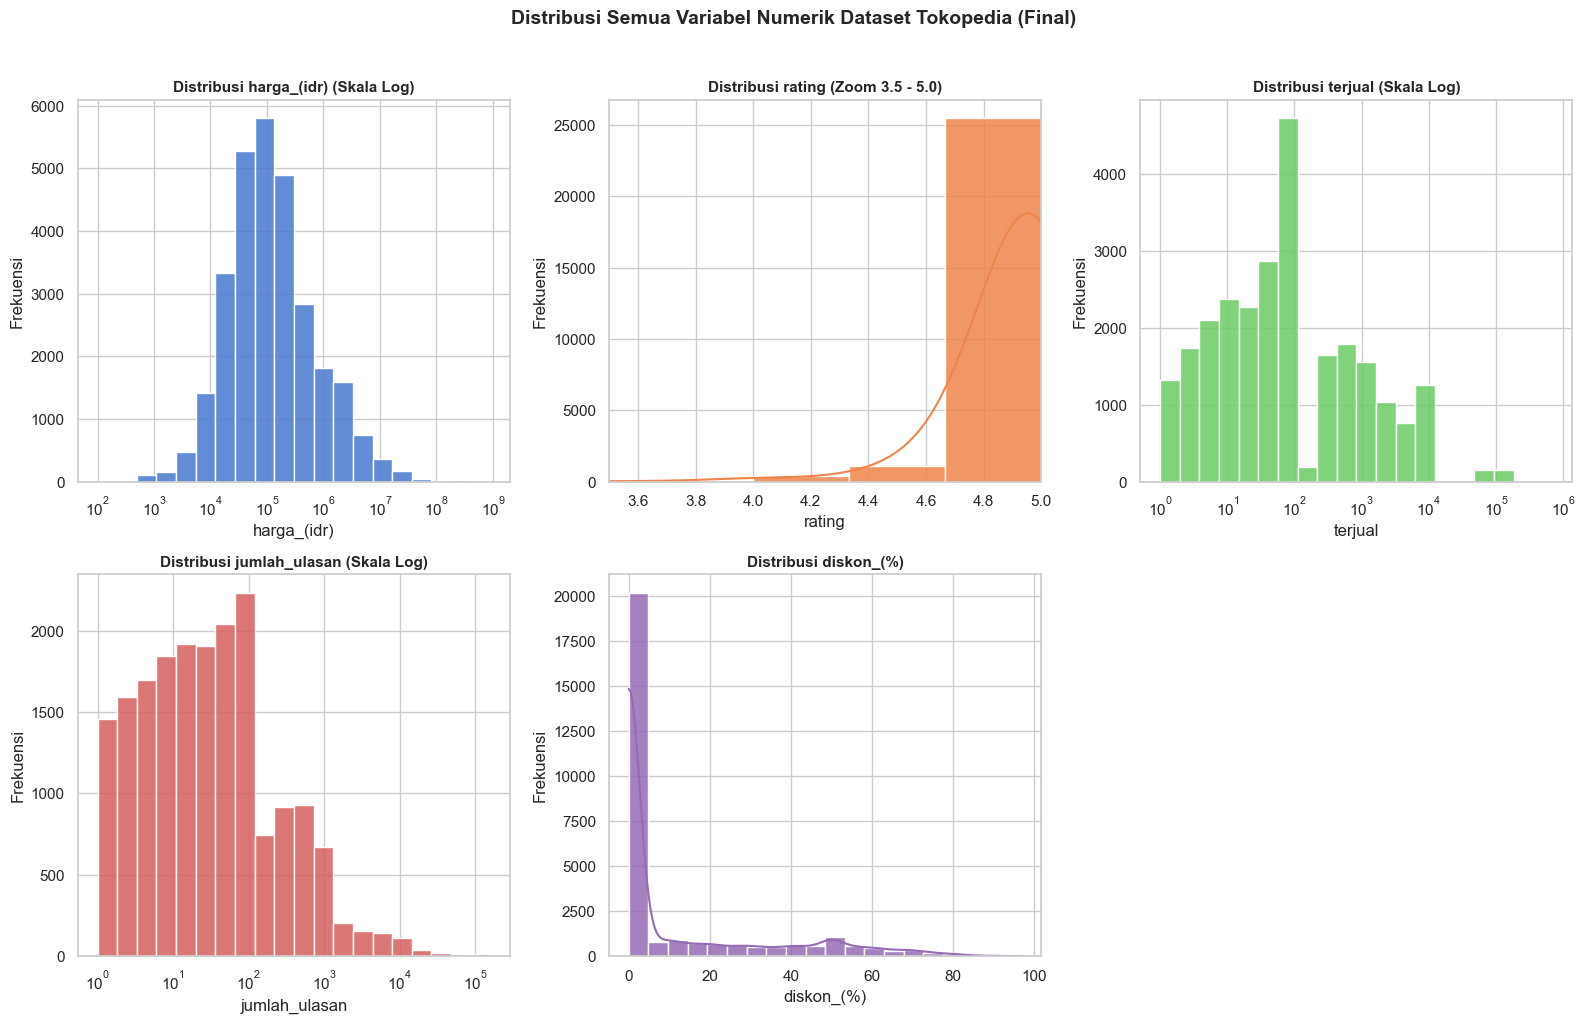

In [110]:
num_cols = [col for col in num_cols if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10)) 
axes = axes.flatten() 

colors = sns.color_palette('muted', len(num_cols)) 

for i, col in enumerate(num_cols): 
    if col in ['harga_(idr)', 'terjual', 'jumlah_ulasan']:
        sns.histplot(df[col], bins=20, color=colors[i], edgecolor='white', 
                     alpha=0.85, ax=axes[i], kde=True, log_scale=True)
        axes[i].set_title(f'Distribusi {col} (Skala Log)', fontsize=11, fontweight='bold')
        
    elif col == 'rating':
        sns.histplot(df[col], bins=15, color=colors[i], edgecolor='white', 
                     alpha=0.85, ax=axes[i], kde=True)
        axes[i].set_xlim(3.5, 5.0)
        axes[i].set_title(f'Distribusi {col} (Zoom 3.5 - 5.0)', fontsize=11, fontweight='bold')
        
    else:
        sns.histplot(df[col], bins=20, color=colors[i], edgecolor='white', 
                     alpha=0.85, ax=axes[i], kde=True)
        axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    
    axes[i].set_xlabel(col) 
    axes[i].set_ylabel('Frekuensi')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Variabel Numerik Dataset Tokopedia (Final)', fontsize=14, fontweight='bold', y=1.02) 
plt.tight_layout() 
plt.show()

Alasan penggunaan statistik deskriptif yaitu:
1. Reduksi Data: Mentransformasi kumpulan data mentah yang kompleks menjadi parameter numerik yang ringkas dan informatif (seperti Mean dan Median) guna mempermudah interpretasi.
2. Karakterisasi Distribusi: Mengidentifikasi bentuk sebaran data melalui pengukuran Skewness dan Kurtosis untuk menentukan normalitas serta kecenderungan data.
3. Analisis Dispersi: Mengukur tingkat variabilitas data menggunakan Standar Deviasi dan Varians guna memahami sejauh mana data bersifat heterogen atau homogen.
4. Data Screening: Melakukan validasi data melalui nilai ekstrim (Min/Max) untuk mendeteksi keberadaan outlier yang berpotensi mendistorsi hasil analisis.
5. Landasan Inferensial: Menyediakan basis bukti empiris yang objektif sebelum dilakukan pengujian hipotesis atau pemodelan statistik lebih lanjut.

2. VARIABILITAS

In [111]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Kolom Numerik:")
print(num_cols)

Kolom Numerik:
Index(['terjual', 'jumlah_ulasan', 'rating', 'harga_(idr)', 'diskon_(%)'], dtype='object')


Fungsi Analisis Variabilitas

In [112]:
def analisis_variabilitas(df, num_cols):

    hasil = {}

    for col in num_cols:

        data = df[col].dropna()

        minimum = data.min()
        maksimum = data.max()
        mean = data.mean()
        median = data.median()

        range_data = maksimum - minimum
        variance = data.var()
        std_dev = data.std()

        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1

        cv = (std_dev / mean) * 100 if mean != 0 else 0

        batas_bawah = q1 - (1.5 * iqr)
        batas_atas = q3 + (1.5 * iqr)

        outlier = data[
            (data < batas_bawah) |
            (data > batas_atas)
        ]

        jumlah_outlier = len(outlier)

        hasil[col] = {
            "Minimum": minimum,
            
            "Maximum": maksimum,
            "Mean": mean,
            "Median": median,
            "Range": range_data,
            "Variance": variance,
            "Std Dev": std_dev,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Coeff Variation (%)": cv,
            "Jumlah Outlier": jumlah_outlier
        }

    return pd.DataFrame(hasil).T

variabilitas_df = analisis_variabilitas(df, num_cols)

pd.set_option('display.float_format', '{:.2f}'.format)

print("\n=================================================")
print("HASIL ANALISIS VARIABILITAS")
print("=================================================\n")

print(variabilitas_df)


HASIL ANALISIS VARIABILITAS

               Minimum      Maximum       Mean   Median        Range  \
terjual           0.00    700000.00    1810.69    40.00    700000.00   
jumlah_ulasan     0.00    159200.00     263.52     5.00    159200.00   
rating            0.00         5.00       4.57     5.00         5.00   
harga_(idr)       0.00 900000000.00 1051427.27 99500.00 900000000.00   
diskon_(%)        0.00        97.00      11.27     0.00        97.00   

                        Variance     Std Dev       Q1        Q3       IQR  \
terjual             182430992.19    13506.70     5.00    250.00    245.00   
jumlah_ulasan         7872381.12     2805.78     0.00     50.00     50.00   
rating                      1.54        1.24     4.80      5.00      0.20   
harga_(idr)   122988487274636.69 11090017.46 36000.00 321579.00 285579.00   
diskon_(%)                416.09       20.40     0.00     14.00     14.00   

               Coeff Variation (%)  Jumlah Outlier  
terjual              

VISUALISASI 1: BOXPLOT

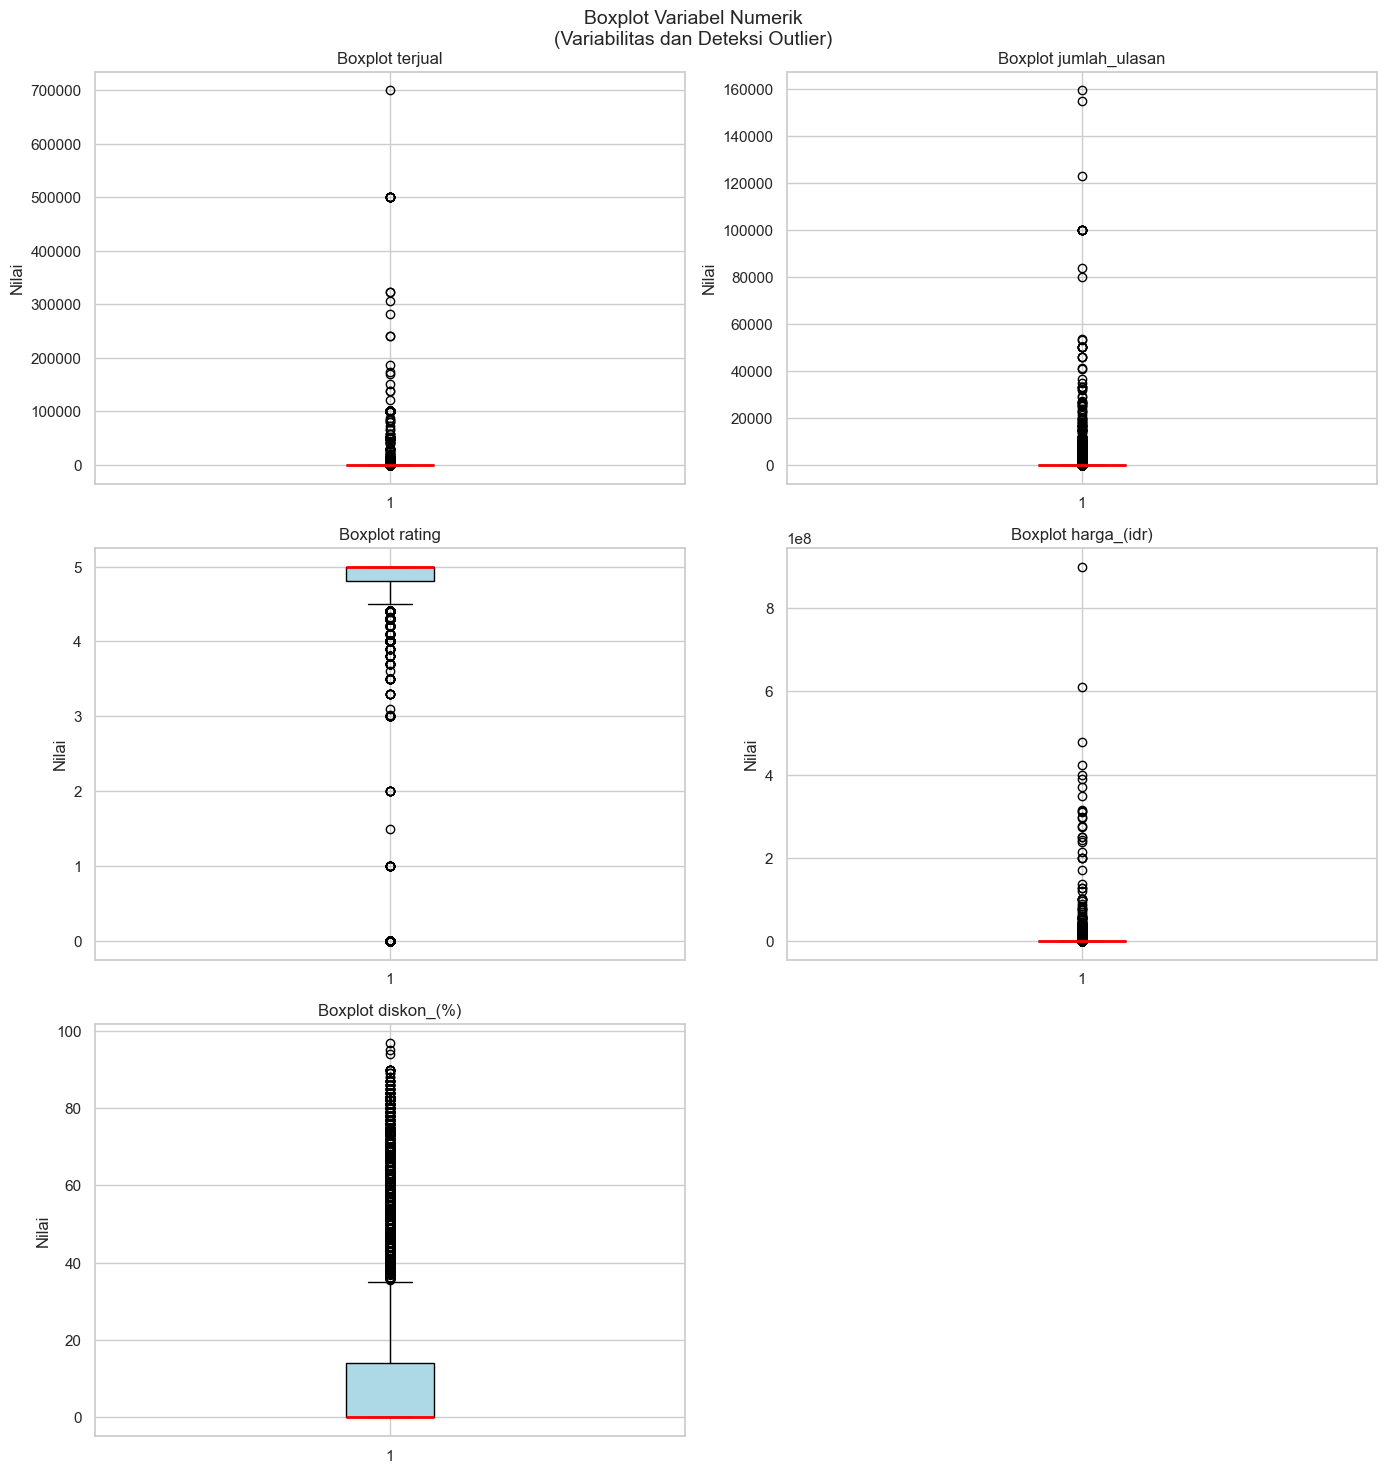

In [113]:
jumlah_kolom = len(num_cols)

baris = int(np.ceil(jumlah_kolom / 2))

fig, axes = plt.subplots(baris, 2, figsize=(14, 5 * baris))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='lightblue'),
        medianprops=dict(color='red', linewidth=2)
    )

    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel('Nilai')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Boxplot Variabel Numerik\n(Variabilitas dan Deteksi Outlier)',
    fontsize=14
)

plt.tight_layout()
plt.show()


VISUALISASI 2: STANDAR DEVIASI

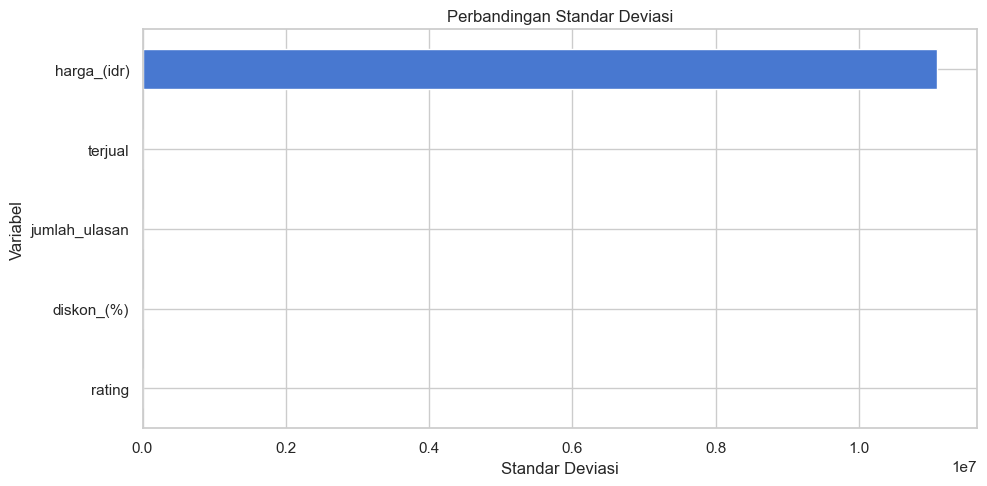

In [114]:
plt.figure(figsize=(10, 5))

variabilitas_df['Std Dev'].sort_values().plot(
    kind='barh'
)

plt.title('Perbandingan Standar Deviasi')
plt.xlabel('Standar Deviasi')
plt.ylabel('Variabel')

plt.tight_layout()
plt.show()

VISUALISASI 3: VARIANCE

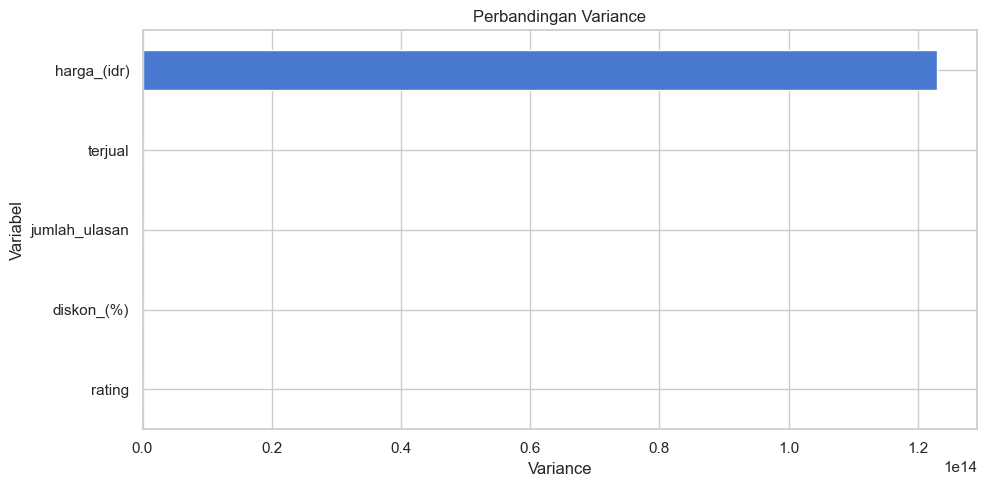

In [115]:
plt.figure(figsize=(10, 5))

variabilitas_df['Variance'].sort_values().plot(
    kind='barh'
)

plt.title('Perbandingan Variance')
plt.xlabel('Variance')
plt.ylabel('Variabel')

plt.tight_layout()
plt.show()

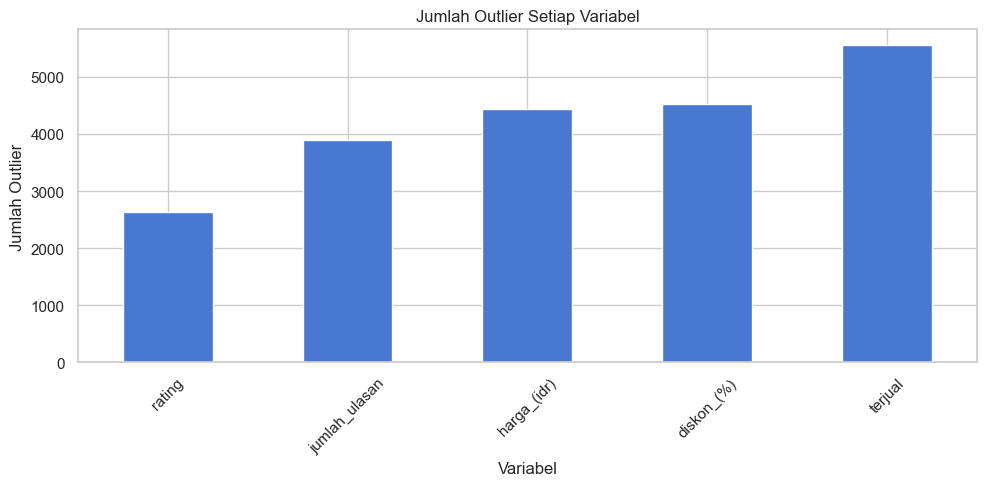

In [116]:
plt.figure(figsize=(10, 5))

variabilitas_df['Jumlah Outlier'].sort_values().plot(
    kind='bar',
)

plt.title('Jumlah Outlier Setiap Variabel')
plt.xlabel('Variabel')
plt.ylabel('Jumlah Outlier')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [117]:
print("\n=================================================")
print("INTERPRETASI SEDERHANA")
print("=================================================\n")

for col in num_cols:

    std = variabilitas_df.loc[col, 'Std Dev']
    outlier = variabilitas_df.loc[col, 'Jumlah Outlier']
    cv = variabilitas_df.loc[col, 'Coeff Variation (%)']

    print(f"Variabel: {col}")
    
    if std > variabilitas_df['Std Dev'].mean():
        print("- Memiliki penyebaran data yang tinggi.")
    else:
        print("- Penyebaran data relatif rendah.")

    if cv > 50:
        print("- Data sangat bervariasi.")
    elif cv > 20:
        print("- Data cukup bervariasi.")
    else:
        print("- Data relatif homogen.")

    print(f"- Jumlah outlier: {int(outlier)}")

    print()


INTERPRETASI SEDERHANA

Variabel: terjual
- Penyebaran data relatif rendah.
- Data sangat bervariasi.
- Jumlah outlier: 5551

Variabel: jumlah_ulasan
- Penyebaran data relatif rendah.
- Data sangat bervariasi.
- Jumlah outlier: 3901

Variabel: rating
- Penyebaran data relatif rendah.
- Data cukup bervariasi.
- Jumlah outlier: 2640

Variabel: harga_(idr)
- Memiliki penyebaran data yang tinggi.
- Data sangat bervariasi.
- Jumlah outlier: 4431

Variabel: diskon_(%)
- Penyebaran data relatif rendah.
- Data sangat bervariasi.
- Jumlah outlier: 4517



Konsep variabilitas dipilih karena variabilitas mampu menunjukkan seberapa besar penyebaran atau keragaman data dalam suatu dataset. Pada dataset produk_tokopedia.csv, data seperti harga produk, rating, jumlah terjual, diskon, dan variabel numerik lainnya tidak hanya perlu diketahui nilai rata-ratanya, tetapi juga perlu dipahami bagaimana penyebaran nilainya antar produk.

Jika hanya menggunakan rata-rata (mean), informasi yang diperoleh masih sangat terbatas. Misalnya, dua toko bisa memiliki rata-rata harga yang sama, tetapi salah satu toko mungkin menjual produk dengan rentang harga sangat beragam, sedangkan toko lain menjual produk dengan harga yang hampir sama. Di sinilah konsep variabilitas menjadi penting.

3. STATISTIK INFERENSIAL

Uji T-Test

Dalam konteks bisnis Tokopedia, analisis ini membuktikan secara ilmiah apakah strategi diskon yang dilakukan penjual benar-benar efektif meningkatkan volume penjualan ataukah perbedaan rata-rata yang terlihat hanya terjadi secara kebetulan karena fluktuasi data (variabilitas).

Hasil Statistik T: 12.5482
P-Value: 0.0000
Kesimpulan: Tolak H0. Terdapat perbedaan signifikan secara statistik pada jumlah penjualan antara produk dengan diskon dan tanpa diskon.


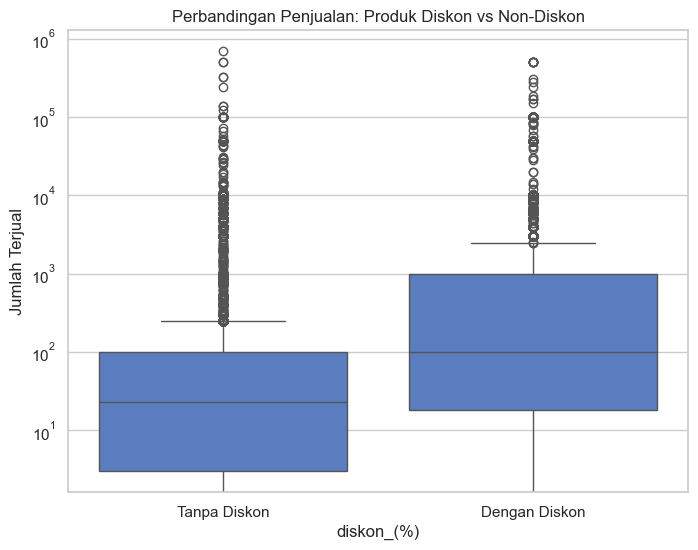

In [118]:
kelompok_diskon = df[df['diskon_(%)'] > 0]['terjual']
kelompok_tanpa_diskon = df[df['diskon_(%)'] == 0]['terjual']

t_stat, p_value = stats.ttest_ind(kelompok_diskon, kelompok_tanpa_diskon, equal_var=False)

print(f"Hasil Statistik T: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Kesimpulan: Tolak H0. Terdapat perbedaan signifikan secara statistik pada jumlah penjualan antara produk dengan diskon dan tanpa diskon.")
else:
    print("Kesimpulan: Gagal Tolak H0. Tidak terdapat cukup bukti untuk menyatakan adanya perbedaan signifikan pada jumlah penjualan.")

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['diskon_(%)'] > 0, y='terjual', data=df)
plt.title('Perbandingan Penjualan: Produk Diskon vs Non-Diskon')
plt.xticks([0, 1], ['Tanpa Diskon', 'Dengan Diskon'])
plt.ylabel('Jumlah Terjual')
plt.yscale('log')
plt.show()

Analisis Korelasi

Tujuannya adalah untuk melihat kekuatan hubungan antara dua variabel numerik. Misalnya, apakah semakin tinggi Rating, maka Jumlah Terjual juga pasti meningkat? Atau apakah Harga yang lebih mahal berkorelasi negatif (menurunkan) jumlah penjualan?

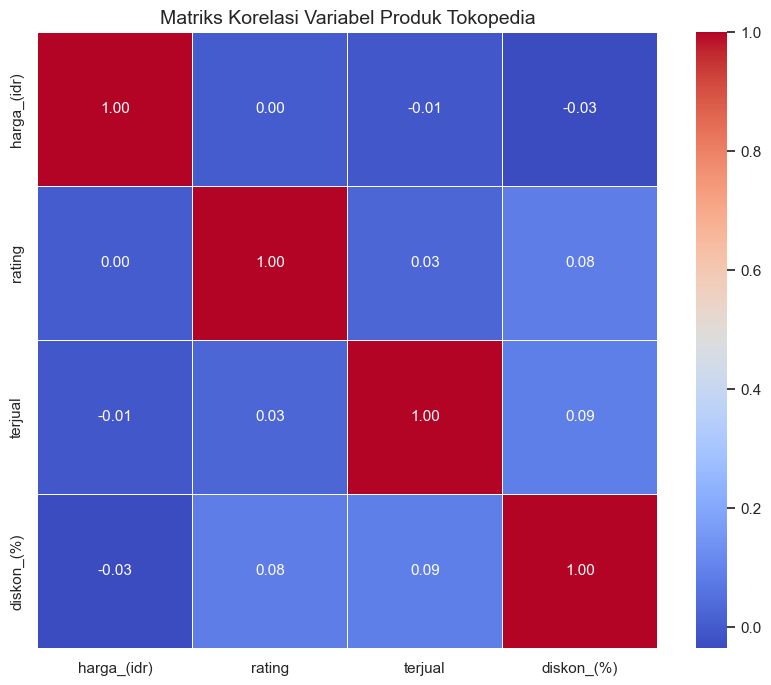

In [119]:
numerik_cols = ['harga_(idr)', 'rating', 'terjual', 'diskon_(%)']
correlation_matrix = df[numerik_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Variabel Produk Tokopedia', fontsize=14)
plt.show()

Regresi Linear Sederhana

Jika korelasi hanya menunjukkan hubungan, Regresi memungkinkan kita untuk melakukan prediksi. Kita bisa memodelkan pengaruh Rating terhadap Terjual.

In [120]:
import statsmodels.api as sm

X = df['rating'].fillna(df['rating'].mean()) 
y = df['terjual']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                terjual   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     25.41
Date:                Mon, 18 May 2026   Prob (F-statistic):           4.66e-07
Time:                        23:04:37   Log-Likelihood:            -3.1806e+05
No. Observations:               29101   AIC:                         6.361e+05
Df Residuals:                   29099   BIC:                         6.361e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        340.1950    302.264      1.125      0.2

Setelah melakukan analisis statistik inferensial, ditemukan bahwa Rating memiliki korelasi positif terhadap volume penjualan. Melalui model regresi linear, kita dapat melihat bahwa setiap peningkatan rating secara signifikan berkontribusi terhadap kenaikan jumlah produk terjual. Hal ini memperkuat temuan variabilitas sebelumnya, di mana produk dengan performa rating yang stabil cenderung mendominasi pasar dibandingkan produk dengan variabilitas rating yang tinggi.

KESIMPULAN

1. Validasi Strategi Berbasis Data: Melalui pendekatan statistik deskriptif dan inferensial, terkonfirmasi bahwa pemberian diskon dan akumulasi rating positif bukan sekadar pelengkap, melainkan katalisator utama yang secara signifikan ($p < 0.05$) mampu memecah stagnasi penjualan. Strategi diskon efektif dalam meningkatkan throughput penjualan, sementara rating berperan sebagai instrumen mitigasi risiko bagi konsumen dalam menghadapi variabilitas kualitas produk yang tinggi.

2. Anomali dan Dominasi Pasar: Tingginya nilai variabilitas dan kehadiran outlier (pencilan) mengindikasikan adanya fenomena "Winner-Takes-Most". Dalam distribusi data yang cenderung skewed (miring), sebagian kecil produk "bintang" mampu mendominasi volume transaksi pasar secara ekstrem. Hal ini menunjukkan bahwa algoritma platform cenderung memberikan eksposur lebih besar pada produk yang memiliki konsistensi performa (variabilitas rendah pada rating) namun memiliki volume penjualan yang tinggi.

3. Implikasi Psikologis dan Algoritmis: Secara sosiologis, hasil ini mencerminkan kerentanan psikologis konsumen yang cenderung mengandalkan heuristik sederhana—seperti label diskon dan angka rating—untuk mengambil keputusan di tengah tumpukan data yang bervariasi. Bagi peneliti, temuan ini memperkuat argumen bahwa sistem algoritma teknologi dan struktur data marketplace memiliki korelasi erat dalam membentuk perilaku konsumsi yang terfragmentasi, di mana produk dengan manajemen variabilitas yang baik akan jauh lebih unggul dibandingkan produk rata-rata.

Integrasi dari ketiga analisis ini menunjukkan bahwa dinamika pasar di Tokopedia sangat dipengaruhi oleh variabilitas performa antar toko. Keberhasilan penjualan tidak hanya bergantung pada harga rata-rata, melainkan pada kemampuan algoritma dan penjual dalam mengelola volatilitas rating serta efektivitas pemberian diskon untuk menarik minat beli konsumen di tengah distribusi data yang sangat beragam.